# **Automatidata project**
**Classification Analysis:** Learning the complex patterns of tipping customers

# Build a binary classification model

**Part 1:** Ethical considerations 
    
- &emsp; Consider the ethical implications of the request 
- &emsp; Should the objective of the model be adjusted?

**Part 2:** Feature engineering & Data Preprocesssing

- &emsp; Perform feature selection, extraction, and transformation to prepare the data for modeling

**Part 3:** Modeling

- &emsp; Build the models, evaluate them, and advise on next steps

**The goal** of this project is to build a machine learning model to use in an app that will alert taxi drivers to customers who are likely to tip generously, as a way to generate more revenue for taxi cab drivers. 

When the model says a customer will give a tip, but they actually won't.
* It is likely to disincentivize drivers from picking up customers and promoting good services to customers. If it happened often, drivers might not trust the app. It could also cause a customer backlash.

When the model says a customer will not give a tip, but they actually will.
* It is likely to inflate drivers' expectations on all riders, soon making it a customary obligation for a customer to offer a tip upfront to access to a taxi service.

To avoid limiting equal access to taxis, which can be ethically problematic, the modeling objective is revised to predict people who are particularly generous—those tipping 20% or more, and predominantly assigned to top rating drivers as rewards.

### **Task 1. Imports and data loading**

In [1]:
# Import packages and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Begin by reading in the data. There are two dataframes: one containing the original data, the other containing the mean durations, mean distances, and predicted fares from the previous project called nyc_selfpreds_means.csv.

In [2]:
# RUN THIS CELL TO SEE ALL COLUMNS 
pd.set_option('display.max_columns', None)

In [3]:
# Load dataset into dataframe
cleaned_df = pd.read_csv('Clean_2017_Taxi_Trip_Data.csv', index_col=0,
                         parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'],
                         date_format="%Y-%m-%d %H:%M:%S")

# Import predicted fares and mean distance and duration from previous course
preds_means_df = pd.read_csv('nyc_selfpreds_means.csv', index_col=0)

In [4]:
# Inspect the first few rows of df0
cleaned_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,14.1,6,3.34,1,100,231,1,13.0,2.76,0.0,16.56
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,26.5,1,1.80,1,186,43,1,16.0,4.00,0.0,20.80
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,7.2,1,1.00,1,262,236,1,6.5,1.45,0.0,8.75
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,30.2,1,3.70,1,188,97,1,20.5,6.39,0.0,27.69
30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,16.7,1,4.37,1,4,112,2,16.5,0.00,0.0,17.80


In [5]:
# Inspect the first few rows of `nyc_preds_means`
preds_means_df.head()

,mean_duration,mean_distance,predicted_fare
87225995,17.460000,2.623000,13.302787
64638886,8.900000,1.510000,8.500028
43194373,10.755556,1.106889,8.138741
72366830,9.800000,0.740000,7.137211
61189839,14.713333,2.036667,11.082804


#### Join the two dataframes

In [6]:
# Combine the cleaned_df with the preds_means_df 
rides_df = pd.concat([cleaned_df, preds_means_df], axis=1, join='inner')
rides_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,mean_duration,mean_distance,predicted_fare
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,14.1,6,3.34,1,100,231,1,13.0,2.76,0.0,16.56,22.516667,3.448333,16.131496
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,26.5,1,1.80,1,186,43,1,16.0,4.00,0.0,20.80,26.500000,1.800000,13.902922
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,7.2,1,1.00,1,262,236,1,6.5,1.45,0.0,8.75,7.331373,0.899216,7.057045
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,30.2,1,3.70,1,188,97,1,20.5,6.39,0.0,27.69,30.200000,3.700000,18.669945
30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,16.7,1,4.37,1,4,112,2,16.5,0.00,0.0,17.80,16.700000,4.370000,16.335110


### **Task 2. Feature engineering**

In [7]:
rides_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22698 entries, 24870114 to 17208911
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               22698 non-null  int64         
 1   tpep_pickup_datetime   22698 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  22698 non-null  datetime64[ns]
 3   trip_duration          22698 non-null  float64       
 4   passenger_count        22698 non-null  int64         
 5   trip_distance          22698 non-null  float64       
 6   RatecodeID             22698 non-null  int64         
 7   PULocationID           22698 non-null  int64         
 8   DOLocationID           22698 non-null  int64         
 9   payment_type           22698 non-null  int64         
 10  fare_amount            22698 non-null  float64       
 11  tip_amount             22698 non-null  float64       
 12  tolls_amount           22698 non-null  float64       
 

- **It's known from the EDA that customers who pay cash generally have a tip amount of $0. To meet the modeling objective, the data for customers who pay with credit card will be sampled.**

In [8]:
# Subset the data to isolate only customers who paid by credit card
rides_df = rides_df.loc[rides_df.payment_type == 1, :].copy()

**Target**- Since there isn't a column that indicates tip percent, it'll need to be engineered from the `tip_amount`. 

In [9]:
# Create tip_pct column
tip_ratio = rides_df['tip_amount'] / (rides_df['total_amount'] - rides_df['tip_amount']) 
rides_df['tip_pct'] = round(tip_ratio, 3) * 100

Now create another column of binary indicator called `generous`, which identifies whether or not a customer tipped ≥ 20% (0=no, 1=yes).

In [10]:
# Create 'generous' col (target)
rides_df['generous'] = (rides_df.tip_pct >= 20).astype(int)
rides_df['generous']

24870114     1
35634249     1
106203690    0
38942136     1
23345809     1
            ..
60425673     1
67858616     1
66632549     1
60217333     0
17208911     0
Name: generous, Length: 15264, dtype: int32

#### Create day column

Create a `day` column that contains only the day of the week when each passenger was picked up. Then, convert the values to lowercase.

In [11]:
# Create a 'day' col
day = rides_df['tpep_pickup_datetime'].dt.day_name().str.slice(stop=3)
rides_df['day'] = day.str.lower()

rides_df['day']

24870114     sat
35634249     tue
106203690    fri
38942136     sun
23345809     sat
            ... 
60425673     sun
67858616     thu
66632549     sun
60217333     sat
17208911     thu
Name: day, Length: 15264, dtype: object

#### Create time of day columns

Next, engineer four new columns that represent time of day bins. Each column should contain binary values (0=no, 1=yes) that indicate whether a trip began (picked up) during the following times:

`am_rush` = [06:00&ndash;10:00)  
`daytime` = [10:00&ndash;16:00)  
`pm_rush` = [16:00&ndash;20:00)  
`nighttime` = [20:00&ndash;06:00)  

In [12]:
# Create 'am_rush' col
rides_df['am_rush'] = rides_df['tpep_pickup_datetime'].dt.hour

# Create 'daytime' col
rides_df['daytime'] = rides_df['tpep_pickup_datetime'].dt.hour

# Create 'pm_rush' col
rides_df['pm_rush'] = rides_df['tpep_pickup_datetime'].dt.hour

# Create 'nighttime' col
rides_df['nighttime'] = rides_df['tpep_pickup_datetime'].dt.hour

In [13]:
# Define 'verify_session' conversion function [06:00–10:00)
classify_session = lambda hour, timerange: hour.isin(timerange).astype(int)

Now, apply the `am_rush()` function to the `am_rush` series to perform the conversion.

In [14]:
# Apply function to the 'am_rush' series
rides_df['am_rush'] = classify_session(rides_df['am_rush'], range(6, 11))

# Apply 'verify_session' function to the 'daytime' series
rides_df['daytime'] = classify_session(rides_df['daytime'], range(10, 17))

# Apply 'pm_rush()' function to the 'pm_rush' series
rides_df['pm_rush'] = classify_session(rides_df['pm_rush'], range(16, 21))

# Apply 'nighttime' function to the 'nighttime' series
nighttime = [20, 21, 22, 23, 0, 1, 2, 3, 4, 5]
rides_df['nighttime'] = classify_session(rides_df['nighttime'], nighttime)

rides_df['am_rush'].head()

24870114     1
35634249     0
106203690    1
38942136     0
23345809     0
Name: am_rush, dtype: int32

#### Create `month` column

In [15]:
# Create 'month' col
month = rides_df['tpep_pickup_datetime'].dt.month_name().str.slice(stop=3)
rides_df['month'] = month.str.lower()

In [16]:
rides_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,mean_duration,mean_distance,predicted_fare,tip_pct,generous,day,am_rush,daytime,pm_rush,nighttime,month
24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,14.1,6,3.34,1,100,231,1,13.0,2.76,0.0,16.56,22.516667,3.448333,16.131496,20.0,1,sat,1,0,0,0,mar
35634249,1,2017-04-11 14:53:28,2017-04-11 15:19:58,26.5,1,1.80,1,186,43,1,16.0,4.00,0.0,20.80,26.500000,1.800000,13.902922,23.8,1,tue,0,1,0,0,apr
106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,7.2,1,1.00,1,262,236,1,6.5,1.45,0.0,8.75,7.331373,0.899216,7.057045,19.9,0,fri,1,0,0,0,dec
38942136,2,2017-05-07 13:17:59,2017-05-07 13:48:14,30.2,1,3.70,1,188,97,1,20.5,6.39,0.0,27.69,30.200000,3.700000,18.669945,30.0,1,sun,0,1,0,0,may
23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,8.0,6,2.30,1,161,236,1,9.0,2.06,0.0,12.36,14.396078,1.994314,10.978705,20.0,1,sat,0,0,1,1,mar


### Task 2a. Isolate modeling variables

Drop features that are redundant, irrelevant, or that will not be available in a deployed environment.

In [17]:
# Examine the distribution of RatecodeID column:
print(rides_df.RatecodeID.value_counts(normalize=True))

RatecodeID
1    0.971108
2    0.024044
5    0.003079
3    0.001572
4    0.000197
Name: proportion, dtype: float64


- The `RatecodeID` is heavily biased which means there could 
hardly be any significant predictive value from the different groups to the target. 

In [18]:
drop_cols = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_duration',
             'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount',
             'tip_amount', 'tolls_amount', 'total_amount', 'tip_pct']
rides_df = rides_df.drop(columns=drop_cols, errors='ignore')
rides_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15264 entries, 24870114 to 17208911
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   VendorID         15264 non-null  int64  
 1   passenger_count  15264 non-null  int64  
 2   PULocationID     15264 non-null  int64  
 3   DOLocationID     15264 non-null  int64  
 4   mean_duration    15264 non-null  float64
 5   mean_distance    15264 non-null  float64
 6   predicted_fare   15264 non-null  float64
 7   generous         15264 non-null  int32  
 8   day              15264 non-null  object 
 9   am_rush          15264 non-null  int32  
 10  daytime          15264 non-null  int32  
 11  pm_rush          15264 non-null  int32  
 12  nighttime        15264 non-null  int32  
 13  month            15264 non-null  object 
dtypes: float64(3), int32(5), int64(4), object(2)
memory usage: 1.5+ MB


#### Variable encoding

In [19]:
# 1. Convert each column to string
rides_df = rides_df.astype({'VendorID': str, 'PULocationID': str, 'DOLocationID': str})

# 2. Convert categoricals to binary
rides_df = pd.get_dummies(rides_df, drop_first=True, dtype=int)

rides_df.info()

# Note: For factor variables with many levels, we ought to explore the relationships
#       btw the variables & target to determine if all the factors should be retained
#       or consolidated into groups.

<class 'pandas.core.frame.DataFrame'>
Index: 15264 entries, 24870114 to 17208911
Columns: 342 entries, passenger_count to month_sep
dtypes: float64(3), int32(338), int64(1)
memory usage: 20.3 MB


#### Evaluation metric

Before modeling, we must decide on an evaluation metric. 

In [20]:
# Get class balance of 'generous' col
rides_df.generous.value_counts(normalize=True)

generous
1    0.526402
0    0.473598
Name: proportion, dtype: float64

Since the target classes are nearly balanced, we are free to choose the primary evaluation metric solely based on the stakes of errors.  

* False positives are worse for cab drivers, because they would pick up a customer expecting a good tip and then not receive one, frustrating the driver.
* False negatives are worse for customers, because a cab driver would likely pick up a different customer who was predicted to tip more&mdash;even when the original customer would have tipped generously.

**The stakes are relatively even. We want to help taxi drivers make more money, but we don't want this to anger customers. As such F1-metric which weighs both precision and recall equally should be used.**

### **Task 3. Modeling**

In [21]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.model_selection import learning_curve, cross_val_score
import sklearn.metrics as metrics

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# This module lets us save our models once we fit them.
import pickle

from sklearn import set_config
set_config(transform_output="pandas")

In [22]:
# Isolate target variable (y)
y = rides_df.generous

# Isolate the features (X)
X = rides_df.drop(columns='generous')

# Split into train and test sets
X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Standardize the data

Scaling is often encouraged for optimization & distance-based solvers, although it may not be very effective here. 

In [23]:
from sklearn.preprocessing import StandardScaler

# Standardize the X variables
sc_vars = ['mean_distance', 'mean_duration', 'predicted_fare']
sc = StandardScaler()

X_train_scaled = pd.concat([sc.fit_transform(X_train[sc_vars]),
                            X_train.drop(columns=sc_vars)], axis=1)
X_test_scaled = pd.concat([sc.transform(X_test[sc_vars]), 
                           X_test.drop(columns=sc_vars)], axis=1)

X_train_scaled.head(3)

,mean_distance,mean_duration,predicted_fare,passenger_count,am_rush,daytime,pm_rush,nighttime,VendorID_2,PULocationID_10,PULocationID_100,PULocationID_106,PULocationID_107,PULocationID_112,PULocationID_113,PULocationID_114,PULocationID_116,PULocationID_12,PULocationID_123,PULocationID_125,PULocationID_127,PULocationID_128,PULocationID_129,PULocationID_13,PULocationID_130,PULocationID_131,PULocationID_132,PULocationID_133,PULocationID_134,PULocationID_135,PULocationID_137,PULocationID_138,PULocationID_140,PULocationID_141,PULocationID_142,PULocationID_143,PULocationID_144,PULocationID_145,PULocationID_146,PULocationID_148,PULocationID_151,PULocationID_152,PULocationID_153,PULocationID_158,PULocationID_161,PULocationID_162,PULocationID_163,PULocationID_164,PULocationID_166,PULocationID_17,PULocationID_170,PULocationID_173,PULocationID_179,PULocationID_181,PULocationID_186,PULocationID_188,PULocationID_189,PULocationID_190,PULocationID_193,PULocationID_196,PULocationID_208,PULocationID_209,PULocationID_211,PULocationID_213,PULocationID_216,PULocationID_218,PULocationID_223,PULocationID_224,PULocationID_225,PULocationID_226,PULocationID_229,PULocationID_230,PULocationID_231,PULocationID_232,PULocationID_233,PULocationID_234,PULocationID_236,PULocationID_237,PULocationID_238,PULocationID_239,PULocationID_24,PULocationID_243,PULocationID_244,PULocationID_246,PULocationID_247,PULocationID_249,PULocationID_25,PULocationID_255,PULocationID_256,PULocationID_258,PULocationID_260,PULocationID_261,PULocationID_262,PULocationID_263,PULocationID_264,PULocationID_265,PULocationID_28,PULocationID_33,PULocationID_35,PULocationID_36,PULocationID_37,PULocationID_4,PULocationID_40,PULocationID_41,PULocationID_42,PULocationID_43,PULocationID_45,PULocationID_48,PULocationID_49,PULocationID_50,PULocationID_52,PULocationID_57,PULocationID_61,PULocationID_62,PULocationID_65,PULocationID_66,PULocationID_68,PULocationID_7,PULocationID_70,PULocationID_74,PULocationID_75,PULocationID_79,PULocationID_80,PULocationID_82,PULocationID_87,PULocationID_88,PULocationID_90,PULocationID_91,PULocationID_92,PULocationID_93,PULocationID_95,PULocationID_97,DOLocationID_10,DOLocationID_100,DOLocationID_102,DOLocationID_106,DOLocationID_107,DOLocationID_11,DOLocationID_112,DOLocationID_113,DOLocationID_114,DOLocationID_116,DOLocationID_117,DOLocationID_118,DOLocationID_119,DOLocationID_12,DOLocationID_120,DOLocationID_121,DOLocationID_123,DOLocationID_124,DOLocationID_125,DOLocationID_126,DOLocationID_127,DOLocationID_129,DOLocationID_13,DOLocationID_130,DOLocationID_131,DOLocationID_132,DOLocationID_133,DOLocationID_134,DOLocationID_135,DOLocationID_136,DOLocationID_137,DOLocationID_138,DOLocationID_14,DOLocationID_140,DOLocationID_141,DOLocationID_142,DOLocationID_143,DOLocationID_144,DOLocationID_145,DOLocationID_146,DOLocationID_147,DOLocationID_148,DOLocationID_15,DOLocationID_151,DOLocationID_152,DOLocationID_153,DOLocationID_157,DOLocationID_158,DOLocationID_159,DOLocationID_16,DOLocationID_160,DOLocationID_161,DOLocationID_162,DOLocationID_163,DOLocationID_164,DOLocationID_166,DOLocationID_168,DOLocationID_169,DOLocationID_17,DOLocationID_170,DOLocationID_173,DOLocationID_174,DOLocationID_175,DOLocationID_177,DOLocationID_178,DOLocationID_179,DOLocationID_180,DOLocationID_181,DOLocationID_182,DOLocationID_183,DOLocationID_186,DOLocationID_188,DOLocationID_189,DOLocationID_19,DOLocationID_192,DOLocationID_193,DOLocationID_194,DOLocationID_195,DOLocationID_196,DOLocationID_197,DOLocationID_198,DOLocationID_200,DOLocationID_202,DOLocationID_208,DOLocationID_209,DOLocationID_21,DOLocationID_210,DOLocationID_211,DOLocationID_212,DOLocationID_213,DOLocationID_216,DOLocationID_217,DOLocationID_218,DOLocationID_22,DOLocationID_220,DOLocationID_223,DOLocationID_224,DOLocationID_225,DOLocationID_226,DOLocationID_228,DOLocationID_229,DOLocationID_23,DOLocationID_230,DOLocationID_231,DOLocationID_232,DOLocationID_233,DOLocationID_234,DOLocationID_235,DOLocationID_236,DOLocat

We should try out as many ML algorithms there is, to get a sense of the baseline performance and shortlist a few promising ones without spending too much time tweaking the hyperparameters.     

We'll start with non-parametric ML model.  

### KNN Classification

In [26]:
# K-Nearest Neighbors Model
KNN_clf = KNeighborsClassifier()
KNN_clf.fit(X_train_scaled, y_train)

KNN_scores = cross_val_score(KNN_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(KNN_scores).describe()

count    10.000000
mean      0.653462
std       0.012375
min       0.634557
25%       0.643539
50%       0.655726
75%       0.660627
max       0.670189
dtype: float64

### Logistic Regression Classification

In [27]:
# Logistic Regression Model
logit_clf = LogisticRegression(solver='newton-cg', random_state=0)
logit_clf.fit(X_train_scaled, y_train)

logit_scores = cross_val_score(logit_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(logit_scores).describe()

count    10.000000
mean      0.727483
std       0.017274
min       0.702703
25%       0.711541
50%       0.734481
75%       0.737802
max       0.750565
dtype: float64

### Naive-Bayes Classification

In [28]:
# Naive-Bayes Model
NB_clf = BernoulliNB(random_state=0)
NB_clf.fit(X_train_scaled, y_train)

NB_scores = cross_val_score(NB_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(NB_scores).describe()

TypeError: BernoulliNB.__init__() got an unexpected keyword argument 'random_state'

### Decision Tree Classification

In [29]:
# Decision Tree Model
DT_clf = DecisionTreeClassifier(random_state=0)
DT_clf.fit(X_train_scaled, y_train)

DT_scores = cross_val_score(DT_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(DT_scores).describe()

count    10.000000
mean      0.627305
std       0.019739
min       0.592474
25%       0.616921
50%       0.629068
75%       0.634588
max       0.665138
dtype: float64

### Support Vector Machine Classification

In [30]:
# Support Vector Machine Model with different kernel
SVC_clf = SVC(random_state=0)
SVC_clf.fit(X_train_scaled, y_train)

SVC_scores = cross_val_score(SVC_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(SVC_scores).describe()

count    10.000000
mean      0.741956
std       0.017586
min       0.714074
25%       0.725416
50%       0.748278
75%       0.752614
max       0.764835
dtype: float64

### Deep Learning Multi-layer Perceptron Classification

In [31]:
from sklearn.neural_network import MLPClassifier

DL_clf = MLPClassifier(random_state=0, max_iter=300, early_stopping=True)
DL_clf.fit(X_train_scaled, y_train)

DL_scores = cross_val_score(DL_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(DL_scores).describe()

count    10.000000
mean      0.737524
std       0.017799
min       0.713433
25%       0.720025
50%       0.742297
75%       0.749266
max       0.762046
dtype: float64

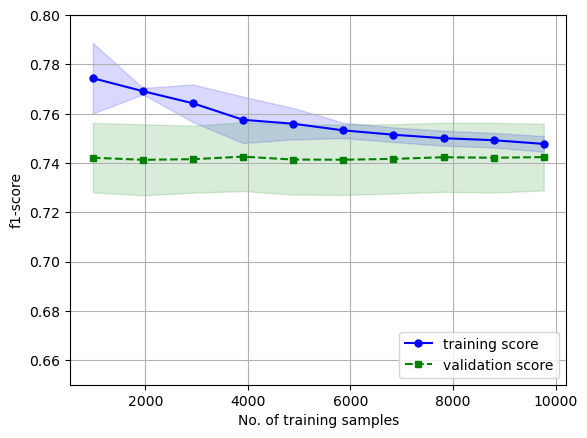

In [61]:
# Diagnosing bias & variance problems with learning curves
train_sizes, train_scores, test_scores = \
    learning_curve(estimator=SVC_clf, X=X_train_scaled, y=y_train, 
                   train_sizes=np.linspace(0.1, 1.0, 10),
                   cv=5, 
                   scoring='f1')

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)
 
plt.figure()
plt.plot(train_sizes, train_mean, color='blue', marker='o',
         markersize=5, label='training score')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s',
         markersize=5, label='validation score')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std,
                 alpha=0.15, color='green')
plt.grid()
plt.ylim([0.65, 0.8])
plt.xlabel('No. of training samples'); plt.ylabel('f1-score')
plt.legend(loc='lower right')
plt.show()

**In summary:** Based on the graph, the model exhibits high bias, as the training and validation lines are located way below the desired score of 80%. This indicates that the model failed to capture the overall pattern in the predictors, probably due to poor features or low complexity algorithm & model.      

The model is not regularized, which rules out the last option. We could try to extract more features, but first we want to try a more complex model to see how it does.  

*Random Forest, AdaBoost, and Gradient Boosting* are among the first models 
we should test, as they require very little preprocessing and they shine with heterogeneous tabular data. They're great for getting a prototype up and running quickly.  

### Ensemble Learning

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Model
RF_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=25,
                                n_jobs=-1, random_state=0)
RF_clf.fit(X_train_scaled, y_train)

RF_scores = cross_val_score(RF_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(RF_scores).describe()

count    10.000000
mean      0.749516
std       0.016464
min       0.723312
25%       0.734271
50%       0.755793
75%       0.760708
max       0.768898
dtype: float64

In [47]:
from sklearn.ensemble import AdaBoostClassifier

# AdaBoost Classifier Model
ADA_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),  # default base estimator
                             n_estimators=200,
                             learning_rate=1.0,
                             random_state=0)
ADA_clf.fit(X_train_scaled, y_train)

ADA_scores = cross_val_score(ADA_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(ADA_scores).describe()

count    10.000000
mean      0.721489
std       0.017147
min       0.690937
25%       0.708103
50%       0.725625
75%       0.730676
max       0.746586
dtype: float64

In [48]:
from xgboost import XGBClassifier

# Gradient Boosting Classification Trees
XGB_clf = XGBClassifier(objective='binary:logistic', 
                        n_estimators=30,
                        random_state=0)
XGB_clf.fit(X_train_scaled, y_train)

XGB_scores = cross_val_score(XGB_clf, X_train_scaled, y_train, scoring='f1', cv=10)
pd.Series(XGB_scores).describe()

count    10.000000
mean      0.740113
std       0.015118
min       0.719183
25%       0.725091
50%       0.744087
75%       0.751760
max       0.756910
dtype: float64

After shortlisting a few promising models: RandomForest & XGBoost, we now need to fine-tune them. 

## Fine-Tuning Models

In [50]:
# 1. Create a dictionary of hyperparameters to tune 
cv_params = {'max_depth': [8, 9, 10],
             'min_samples_split': [0.2],
             'n_estimators': [150, 200],
             'max_features': [8, 'sqrt'],
             'max_samples': [0.8, 0.9, 1.0]}

# 2. Define a set of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 3. Instantiate the GridSearchCV object
RF_clf = GridSearchCV(RandomForestClassifier(random_state=0), 
                      cv_params, 
                      scoring=scoring,
                      cv=5, 
                      refit='f1',
                      n_jobs=-1) 

In [51]:
%%time
RF_clf.fit(X_train_scaled, y_train)

CPU times: total: 2.69 s
Wall time: 51.6 s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0), n_jobs=-1,
             param_grid={'max_depth': [8, 9, 10], 'max_features': [8, 'sqrt'],
                         'max_samples': [0.8, 0.9, 1.0],
                         'min_samples_split': [0.2],
                         'n_estimators': [150, 200]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

Examine the best average score across all the validation folds and the best combination of hyperparameters.

In [52]:
# Examine best score & parameters
print(f'Best score: {RF_clf.best_score_}', 
      f'Best parameters: \n{RF_clf.best_params_}', sep='\n\n')

Best score: 0.751161172528503

Best parameters: 
{'max_depth': 10, 'max_features': 8, 'max_samples': 0.9, 'min_samples_split': 0.2, 'n_estimators': 200}


In [53]:
# 1. Create a dictionary of hyperparameters to tune
xgb_params = {'max_depth': [1, 2, 3],
              'min_child_weight': [1, 2, 3],
              'learning_rate': [0.01, 0.02, 0.03],
              'n_estimators': [200, 225, 250]}

# 2. Define a set of scoring metrics to capture
scoring = ['accuracy', 'precision', 'recall', 'f1']

# 3. Instantiate the GridSearchCV object
XGB_clf = GridSearchCV(XGBClassifier(objective='binary:logistic'), 
                       xgb_params, 
                       scoring=scoring, 
                       cv=5, 
                       refit='f1', 
                       n_jobs=-1)

In [54]:
%%time
XGB_clf.fit(X_train_scaled, y_train)

CPU times: total: 12.7 s
Wall time: 3min 23s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.02, 0.03],
                         'max_depth': [1, 2, 3], 'min_child_weight': [1, 2, 3],
                         'n_estimators': [200, 225, 250]},
             refit='f1', scoring=['accuracy', 'precision', 'recall', 'f1'])

In [55]:
# Examine best score & parameters
print(f'Best score: {XGB_clf.best_score_}', 
      f'Best parameters: \n{XGB_clf.best_params_}', sep='\n\n')

Best score: 0.7496054872153122

Best parameters: 
{'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 200}


In [56]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
    model_name (string): what you want the model to be called in the output table
    model_object: a fit GridSearchCV object
    metric (string): precision, recall, f1, or accuracy

    Returns a pandas df with the F1, recall, precision, and accuracy scores
    for the model with the best mean 'metric' score across all validation folds.
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'precision': 'mean_test_precision',
                 'recall': 'mean_test_recall',
                 'f1': 'mean_test_f1',
                 'accuracy': 'mean_test_accuracy',
                 }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy

    # Create table of results
    table = pd.DataFrame({'model': [model_name],
                        'precision': [precision],
                        'recall': [recall],
                        'F1': [f1],
                        'accuracy': [accuracy],
                        },
                       )

    return table

In [57]:
RF_results = make_results("Tuned RandomForest", RF_clf, 'f1')
XGB_results = make_results("Tuned GradientBoosting", XGB_clf, 'f1')

score_tab = pd.concat([RF_results, XGB_results], axis=0, ignore_index=True)
score_tab

,model,precision,recall,F1,accuracy
0,Tuned RandomForest,0.691916,0.821563,0.751161,0.713536
1,Tuned GradientBoosting,0.693573,0.815649,0.749605,0.713291


- The model performs acceptably. Its F<sub>1</sub> score was 0.7512 and it had an overall accuracy of 0.7135. It correctly identified ~82% of the actual responders in the data, which is 52% better than a random guess. It may be worthwhile to test the model with a select group of taxi drivers to get feedback.  

Plot a confusion matrix of the champion model's predictions on the training data.

In [58]:
# Create a confusion matrix function
def conf_matrix_plot(clf_model, X, y):
    '''
    Accepts as argument model object, X data (test or validate), and y data (test or validate). 
    Returns a plot of confusion matrix for predictions on y data.
    '''
    
    y_pred = clf_model.predict(X)
    cm = metrics.confusion_matrix(y, y_pred, labels=clf_model.classes_)  # for multinomial, use `multilabel_confusion_matrix`
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_model.classes_)

    fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(values_format='', cmap='cividis', ax=ax)  # `values_format=''` suppresses scientific notation
    plt.show()

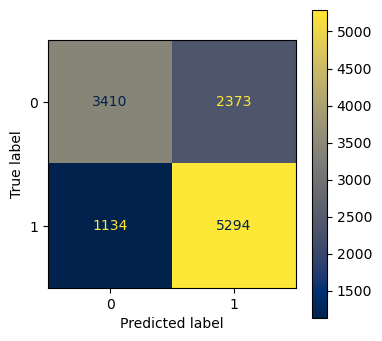

In [59]:
# Examine the confusion matrix for RandomForest model
conf_matrix_plot(RF_clf, X_train_scaled, y_train)

- The confusion matrix indicates that the model is more likely to predict a false positive than a false negative, that is a Type I errors. This is less desirable, because it's better for a driver to be pleasantly surprised by a generous tip when they weren't expecting one than to be disappointed by a low tip when they were expecting a generous one.

##### Feature importance

Inspect the most important features in the model by sorting and plotting them out.  

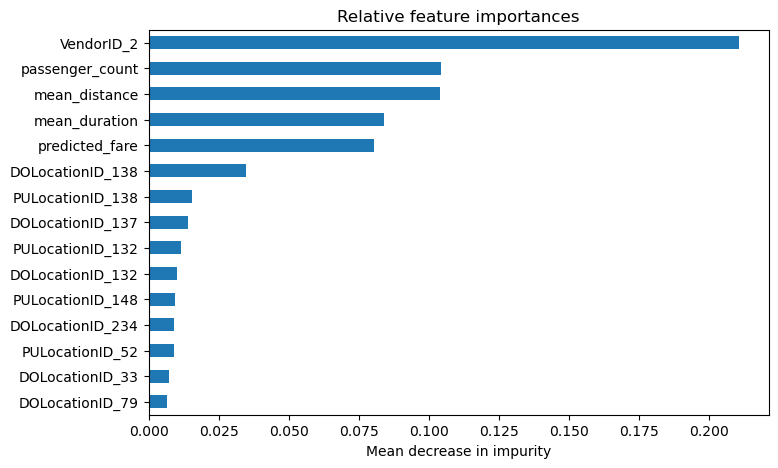

In [60]:
feature_impts = RF_clf.best_estimator_.feature_importances_
RF_importances = (pd.Series(feature_impts, index=X_train.columns)
             .sort_values(ascending=False))[:15]

fig, ax = plt.subplots(figsize=(8,5))
RF_importances[::-1].plot.barh(ax=ax)
ax.set_title('Relative feature importances')
ax.set_xlabel('Mean decrease in impurity')
plt.show()

**From the chart, we know that `VendorID`, `predicted_fare`, `mean_duration`, `mean_distance` and `passenger_count` are the most important features.**

- Unfortunately, RandomForest is not the most transparent ML algorithm that could help in explaining how they influence tipping. This would require further exploration.
- It is interesting that `VendorID` is the most predictive feature. This seems to indicate that one of the two vendors tends to attract more generous customers. It may be worth performing statistical tests on the different vendors to examine this further. 

In [ ]:
import joblib 

# Save the model
joblib.dump(RF_clf.best_estimator_, 'final_mdl.joblib')